# Health Score Analysis - Exploratory Data Analysis

## Purpose
This notebook performs comprehensive EDA to understand and predict health score between company and customers based on:
- Interaction frequency and recency
- Sentiment and engagement metrics
- Contract duration and history
- Support interactions
- Communication patterns
- Account health indicators

## Key Metrics Analyzed
- **Health Score** - Current health score (0-100)
- **Interaction Frequency** - Contact frequency patterns
- **Sentiment Analysis** - Customer sentiment impact on relationship
- **Engagement Metrics** - Response rates and engagement levels
- **Contract Maturity** - HealthScore duration and stability
- **Support Quality** - Support interaction patterns
- **HealthScore Trends** - Improving, stable, or declining relationships

In [7]:
# Install required packages
!uv add pandas numpy matplotlib seaborn openpyxl scikit-learn xgboost lightgbm catboost joblib

Resolved 109 packages in 1ms
Audited 85 packages in 5ms


In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
import joblib
import json

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Advanced Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor,
    StackingRegressor,
    VotingRegressor
)
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore Data

In [9]:
# Load the dataset
possible_paths = [
    Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\customer_data_25000.xlsx"),
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

Column Names:
   1. name
   2. domain
   3. industry
   4. company_size
   5. arr
   6. mrr
   7. contract_start_date
   8. contract_end_date
   9. renewal_date
  10. last_contact_date
  11. status
  12. renewal_stage
  13. health_score
  14. risk_score
  15. relationship_score
  16. churn_probability
  17. sentiment_score
  18. sentiment_category
  19. licenses_total
  20. licenses_used
  21. utilization_percentage
  22. csm_name
  23. csm_email
  24. primary_contact_name
  25. primary_contact_email
  26. primary_contact_phone
  27. salesforce_id

First few rows:


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


## 2. Feature Selection and Transformation

In [10]:
# Factors requested for the model
base_factors = [
    'industry', 'company_size', 'arr', 'mrr', 'renewal_stage',
    'sentiment_score', 'sentiment_category', 'licenses_total',
    'licenses_used', 'utilization_percentage'
]

# Add total_relationship_signal if available
requested_factors = base_factors.copy()
if 'total_relationship_signal' in df.columns:
    requested_factors.append('total_relationship_signal')
    print("✓ total_relationship_signal found in data - will be used as feature")
else:
    print("⚠ total_relationship_signal not found in data - will be skipped")

# Filter the dataframe
df_model = df[requested_factors].copy()

# Custom Logic: if renewal_stage is 'renewed', make it 't_30'

# Verification
print("--- Data Transformation Complete ---")
print(f"Shape: {df_model.shape}")
print("\nDistribution of renewal_stage:")
print(df_model['renewal_stage'].value_counts())
df_model.head()

⚠ total_relationship_signal not found in data - will be skipped
--- Data Transformation Complete ---
Shape: (24874, 10)

Distribution of renewal_stage:
renewal_stage
t90        12412
t60         8136
renewed     4022
t30          304
Name: count, dtype: int64


,industry,company_size,arr,mrr,renewal_stage,sentiment_score,sentiment_category,licenses_total,licenses_used,utilization_percentage
0,Technology,Small,156049,13004.08,t90,0.3353,neutral,20,15,79
1,Healthcare,Medium,517493,43124.42,t90,0.8553,positive,30,23,79
2,Analytics,Large,64898,5408.17,t90,-0.4162,negative,20,14,73
3,Healthcare,Medium,43003,3583.58,t90,0.3132,neutral,20,14,73
4,Enterprise,Medium,100005,8333.75,renewed,0.9937,very_positive,50,33,66


In [22]:
# Prepare data for Health Score prediction
# Use health_score directly from the dataset as target
base_features = [
    'industry', 'company_size', 'arr', 'mrr', 'renewal_stage',
    'sentiment_score', 'sentiment_category', 'licenses_total',
    'licenses_used', 'utilization_percentage'
]

# Add total_relationship_signal if available
input_features = base_features.copy()
if 'total_relationship_signal' in df.columns:
    input_features.append('total_relationship_signal')
    print("✓ total_relationship_signal found in data - will be used as feature")
else:
    print("⚠ total_relationship_signal not found in data - will be skipped")

# Get health_score from original data
df_model = df[input_features + ['health_score']].copy()

# Custom Logic: if renewal_stage is 'renewed', make it 't_30'

print(f"\nData prepared for Health Score prediction:")
print(f"Shape: {df_model.shape}")
print(f"\nHealth Score Statistics:")
print(df_model['health_score'].describe())
print(f"\nDistribution of renewal_stage:")
print(df_model['renewal_stage'].value_counts())

df_model.head()

⚠ total_relationship_signal not found in data - will be skipped

Data prepared for Health Score prediction:
Shape: (24874, 11)

Health Score Statistics:
count    24874.000000
mean        70.217778
std         17.780470
min         30.000000
25%         58.000000
50%         72.000000
75%         83.000000
max        100.000000
Name: health_score, dtype: float64

Distribution of renewal_stage:
renewal_stage
t90        12412
t60         8136
renewed     4022
t30          304
Name: count, dtype: int64


,industry,company_size,arr,mrr,renewal_stage,sentiment_score,sentiment_category,licenses_total,licenses_used,utilization_percentage,health_score
0,Technology,Small,156049,13004.08,t90,0.3353,neutral,20,15,79,62
1,Healthcare,Medium,517493,43124.42,t90,0.8553,positive,30,23,79,77
2,Analytics,Large,64898,5408.17,t90,-0.4162,negative,20,14,73,36
3,Healthcare,Medium,43003,3583.58,t90,0.3132,neutral,20,14,73,44
4,Enterprise,Medium,100005,8333.75,renewed,0.9937,very_positive,50,33,66,78


In [23]:
# Display HealthScore Statistics
# Note: We're using health_score directly from the dataset
print("=" * 60)
print("HealthScore Data Overview")
print("=" * 60)
print(f"\nHealthScore Statistics:")
print(df_model['health_score'].describe())
print(f"\nSample Data (showing key features and target):")
print(df_model[['arr', 'mrr', 'utilization_percentage', 'sentiment_score', 'health_score']].head(10))

HealthScore Data Overview

HealthScore Statistics:
count    24874.000000
mean        70.217778
std         17.780470
min         30.000000
25%         58.000000
50%         72.000000
75%         83.000000
max        100.000000
Name: health_score, dtype: float64

Sample Data (showing key features and target):
      arr       mrr  utilization_percentage  sentiment_score  health_score
0  156049  13004.08                      79           0.3353            62
1  517493  43124.42                      79           0.8553            77
2   64898   5408.17                      73          -0.4162            36
3   43003   3583.58                      73           0.3132            44
4  100005   8333.75                      66           0.9937            78
5  144337  12028.08                      43           0.0995            61
6  263723  21976.92                      45           0.9167            77
7  546412  45534.33                      39           0.8612           100
8  549809  4581

In [24]:
# Save transformed data
output_path = Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\transformed_model_data.xlsx")
output_path.parent.mkdir(parents=True, exist_ok=True)

try:
    df_model.to_excel(output_path, index=False, engine='openpyxl')
    print("--- Success! ---")
    print(f"Data exported to: {output_path}")
    print(f"Total rows dumped: {len(df_model)}")
except Exception as e:
    print(f"Error saving to Excel: {e}")

--- Success! ---
Data exported to: D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\data\transformed_model_data.xlsx
Total rows dumped: 24874


## 3. Categorical Feature Analysis

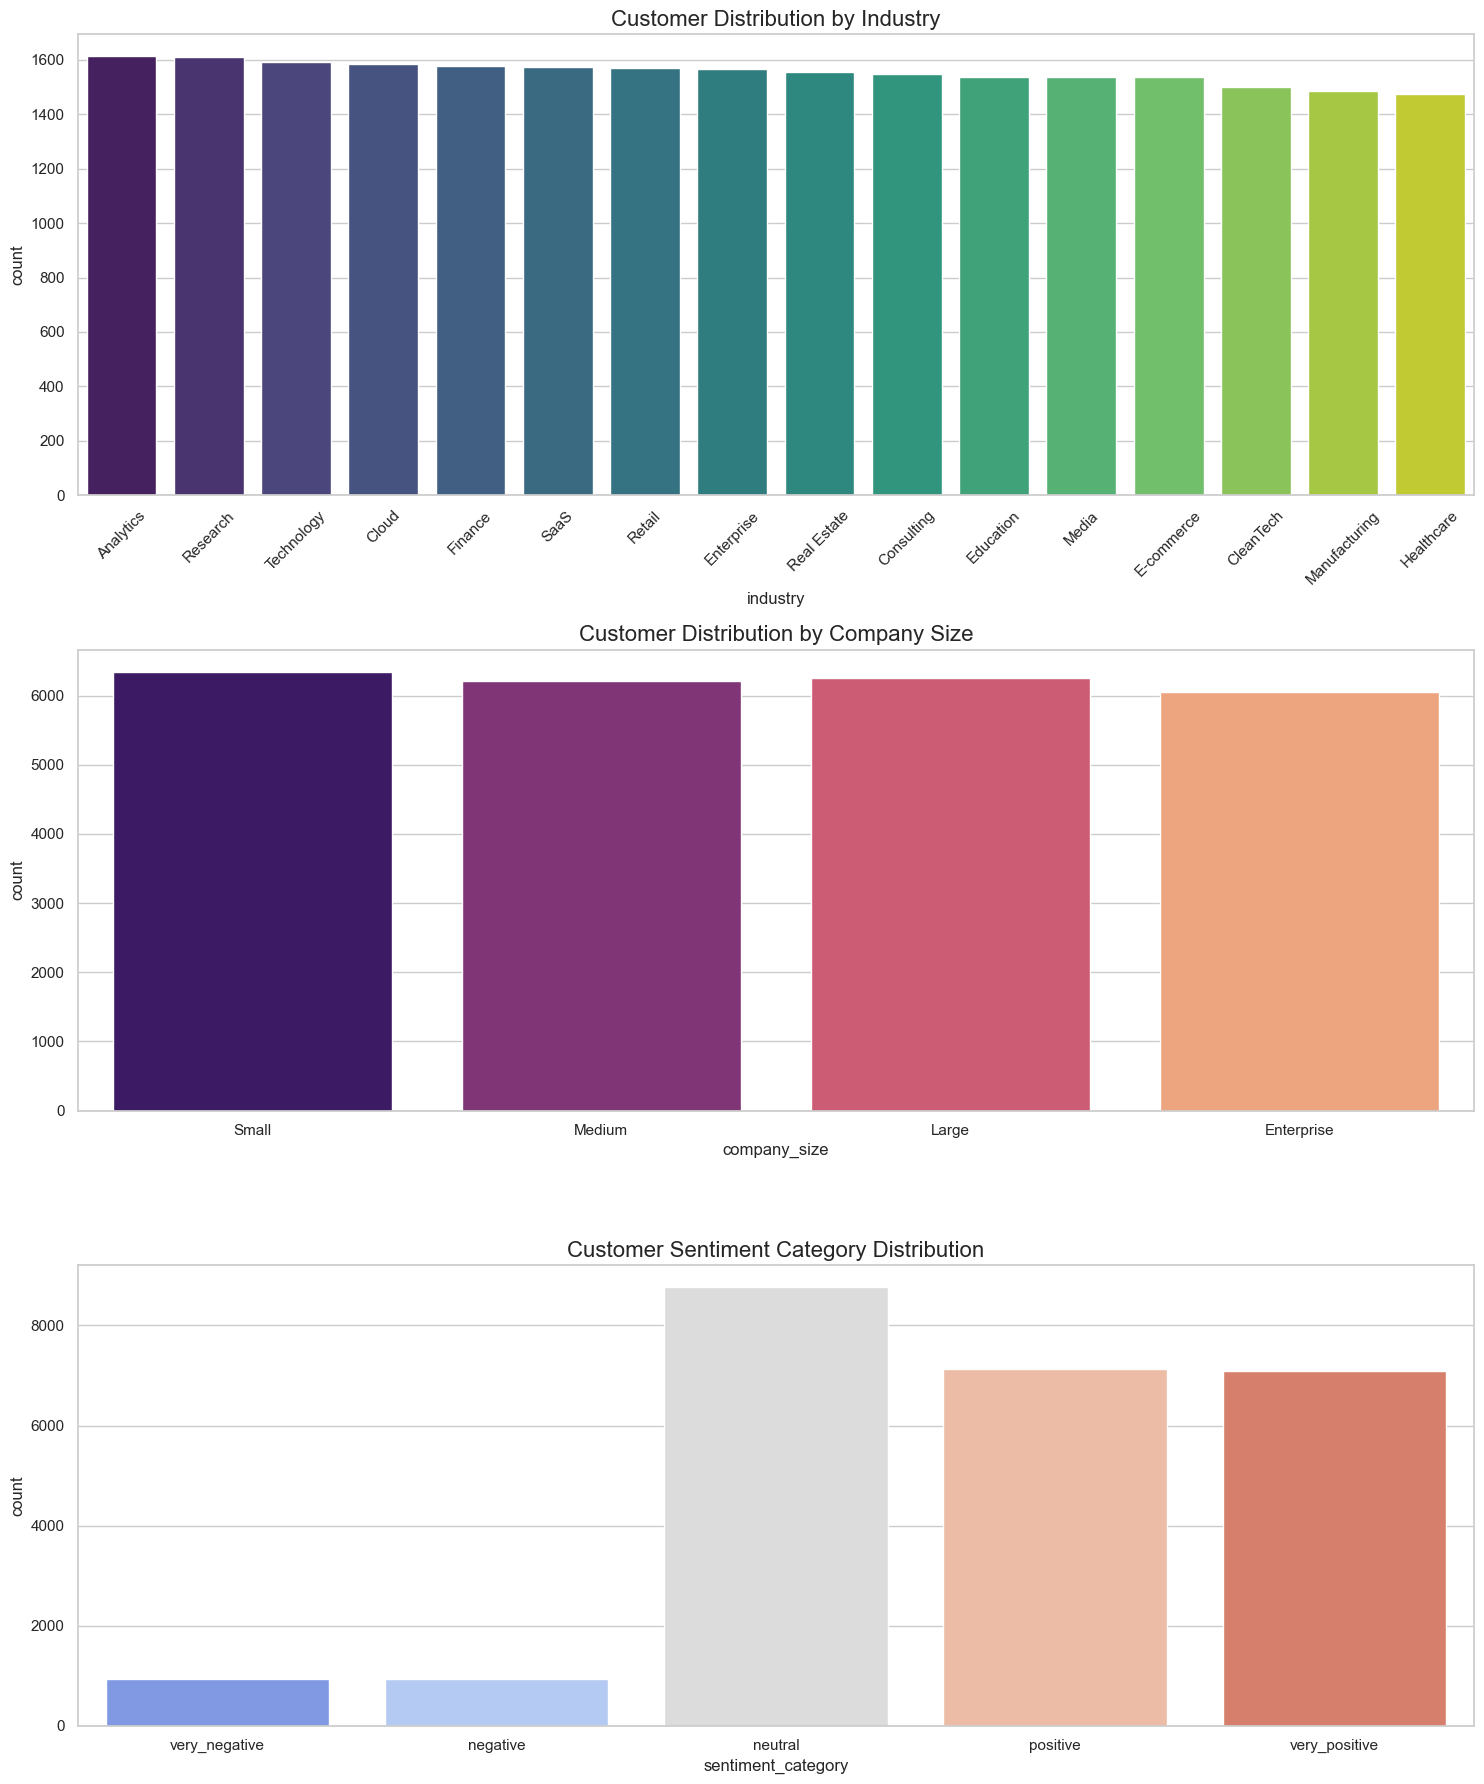


--- INDUSTRY Distribution ---
industry
Analytics        6.484683
Research         6.476642
Technology       6.400257
Cloud            6.372115
Finance          6.343974
SaaS             6.327893
Retail           6.307791
Enterprise       6.303771
Real Estate      6.259548
Consulting       6.231406
Education        6.183163
Media            6.183163
E-commerce       6.183163
CleanTech        6.038434
Manufacturing    5.974110
Healthcare       5.929887
Name: proportion, dtype: float64

--- COMPANY_SIZE Distribution ---
company_size
Small         25.512583
Large         25.158800
Medium        24.969848
Enterprise    24.358768
Name: proportion, dtype: float64

--- SENTIMENT_CATEGORY Distribution ---
sentiment_category
neutral          35.257699
positive         28.648388
very_positive    28.531800
negative          3.787087
very_negative     3.775026
Name: proportion, dtype: float64


In [25]:
# Categorical Feature Distribution Analysis
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# Create a multi-plot figure
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# 1. Industry Distribution
sns.countplot(data=df_model, x='industry', ax=axes[0], palette='viridis', 
              order=df_model['industry'].value_counts().index)
axes[0].set_title('Customer Distribution by Industry', fontsize=16)
axes[0].tick_params(axis='x', rotation=45)

# 2. Company Size Distribution
sns.countplot(data=df_model, x='company_size', ax=axes[1], palette='magma', 
              order=['Small', 'Medium', 'Large', 'Enterprise'])
axes[1].set_title('Customer Distribution by Company Size', fontsize=16)

# 3. Sentiment Category Distribution
sns.countplot(data=df_model, x='sentiment_category', ax=axes[2], palette='coolwarm',
              order=['very_negative', 'negative', 'neutral', 'positive', 'very_positive'])
axes[2].set_title('Customer Sentiment Category Distribution', fontsize=16)

plt.tight_layout()
plt.show()

# Print numerical summaries
for col in ['industry', 'company_size', 'sentiment_category']:
    print(f"\n--- {col.upper()} Distribution ---")
    print(df_model[col].value_counts(normalize=True) * 100)

## 4. Numerical Feature Distribution & Correlation

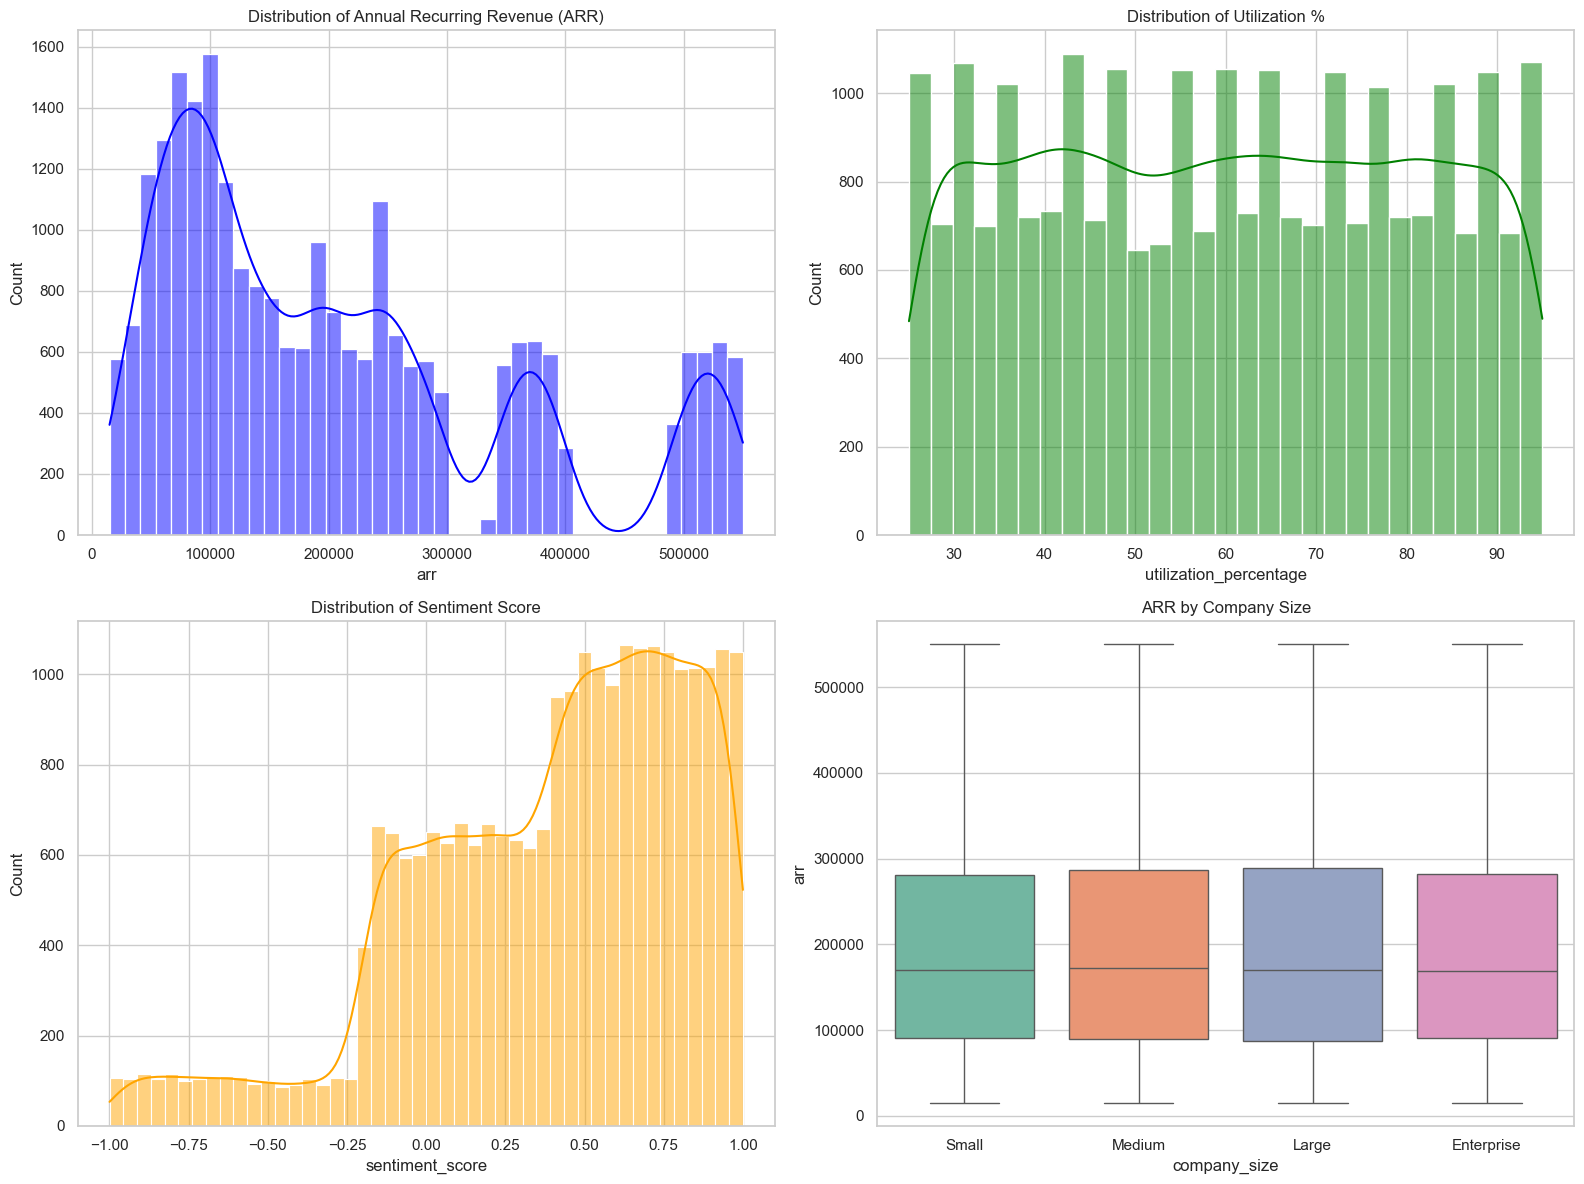

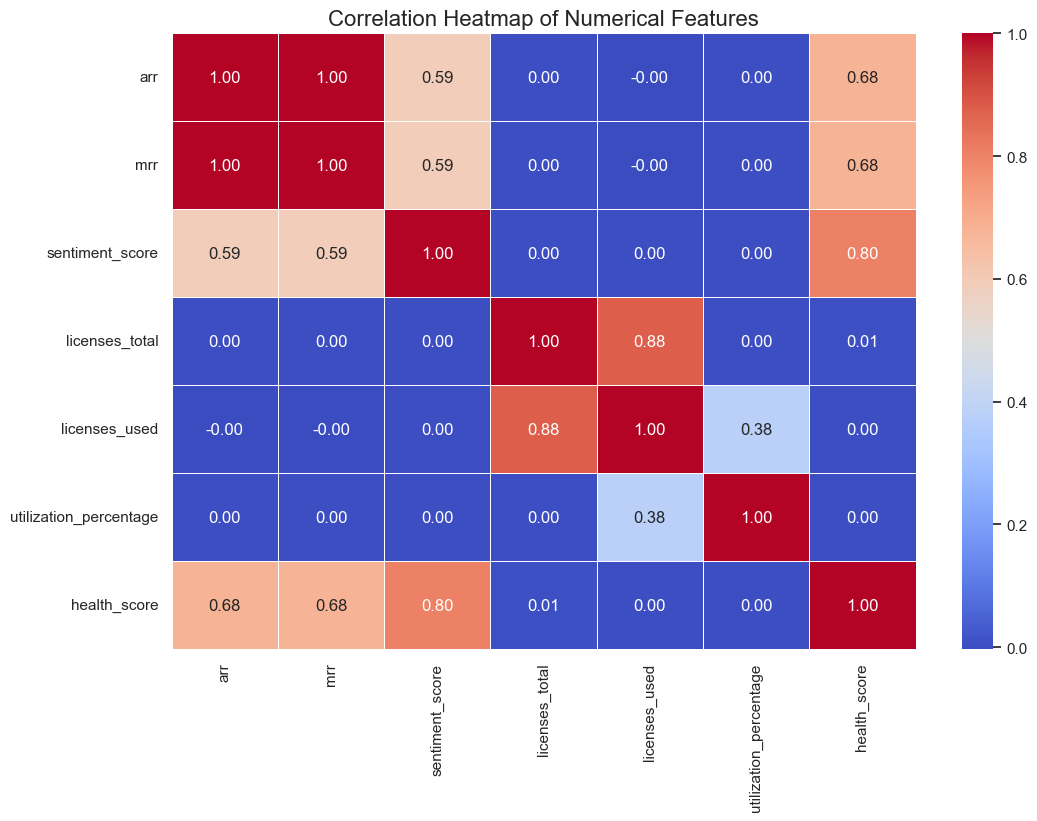


--- Key Statistics ---
                 arr           mrr  sentiment_score  licenses_total  \
count   24874.000000  24874.000000     24874.000000    24874.000000   
mean   208891.058495  17407.588207         0.390492       79.457265   
std    148417.191414  12368.099275         0.438628       62.846458   
min     15019.000000   1251.580000        -0.999400       10.000000   
25%     89990.500000   7499.210000         0.098725       30.000000   
50%    170628.000000  14219.000000         0.477550       75.000000   
75%    284333.750000  23694.480000         0.738200      150.000000   
max    549999.000000  45833.250000         0.999900      200.000000   

       licenses_used  utilization_percentage  health_score  
count   24874.000000            24874.000000  24874.000000  
mean       47.376498               59.956260     70.217778  
std        43.275352               20.503779     17.780470  
min         2.000000               25.000000     30.000000  
25%        14.000000           

In [26]:
# Numerical Feature Distribution & Correlation Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df_model['arr'], kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Distribution of Annual Recurring Revenue (ARR)')

sns.histplot(df_model['utilization_percentage'], kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Distribution of Utilization %')

sns.histplot(df_model['sentiment_score'], kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Distribution of Sentiment Score')

sns.boxplot(data=df_model, x='company_size', y='arr', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('ARR by Company Size')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
numerical_cols = df_model.select_dtypes(include=[np.number]).columns
correlation_matrix = df_model[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

print("\n--- Key Statistics ---")
print(df_model[numerical_cols].describe())

## 5. Baseline Model Training

Initial model training with basic features to establish baseline performance.

In [27]:
# Baseline Model Preparation
y = df_model['health_score']

# Feature Selection (Basic)
features = ['industry', 'company_size', 'arr', 'mrr', 'renewal_stage', 'licenses_total']
X = df_model[features].copy()

# Feature Synergy
X['arr_per_license'] = X['arr'] / X['licenses_total'].replace(0, 1)

# Categorical Encoding
X_encoded = pd.get_dummies(X, columns=['industry', 'company_size', 'renewal_stage'], drop_first=True)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Scaling Numeric Features
numeric_cols = ['arr', 'mrr', 'licenses_total', 'arr_per_license']
scaler = StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled_num = scaler.transform(X_test[numeric_cols])

# Final Feature Matrices
X_train_final = np.hstack([X_train_scaled_num, X_train.drop(columns=numeric_cols).values])
X_test_final = np.hstack([X_test_scaled_num, X_test.drop(columns=numeric_cols).values])

print(f"Data Prepared. Features used: {X_train_final.shape[1]}")
print(f"Train set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

Data Prepared. Features used: 25
Train set: 19,899 samples
Test set: 4,975 samples


In [28]:
# Baseline Model Training
models_baseline = {
    "XGBoost": XGBRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM (SVR)": SVR(kernel='rbf')
}

baseline_results = {}

print("Baseline Model Performance:")
print("=" * 60)

for name, model in models_baseline.items():
    print(f"\n>>> PROCESSING: {name}")
    print("-" * 30)
    
    # Fit
    model.fit(X_train_final, y_train)
    
    # Predict
    preds = model.predict(X_test_final)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    baseline_results[name] = {
        'model': model,
        'r2': r2,
        'mae': mae,
        'rmse': rmse
    }
    
    print(f"Mean Absolute Error (MAE):    {mae:.4f}")
    print(f"Mean Squared Error (MSE):     {mse:.4f}")
    print(f"Root Mean Squared Error(RMSE): {rmse:.4f}")
    print(f"R-Squared (R2) Score:        {r2:.4f}")

print("\n" + "=" * 60)
print("Baseline Training Complete!")
print("=" * 60)

Baseline Model Performance:

>>> PROCESSING: XGBoost
------------------------------
Mean Absolute Error (MAE):    8.5842
Mean Squared Error (MSE):     103.7867
Root Mean Squared Error(RMSE): 10.1876
R-Squared (R2) Score:        0.6712

>>> PROCESSING: Gradient Boosting
------------------------------
Mean Absolute Error (MAE):    8.3982
Mean Squared Error (MSE):     96.5573
Root Mean Squared Error(RMSE): 9.8264
R-Squared (R2) Score:        0.6941

>>> PROCESSING: Random Forest
------------------------------
Mean Absolute Error (MAE):    8.6432
Mean Squared Error (MSE):     107.2696
Root Mean Squared Error(RMSE): 10.3571
R-Squared (R2) Score:        0.6602

>>> PROCESSING: SVM (SVR)
------------------------------
Mean Absolute Error (MAE):    9.0185
Mean Squared Error (MSE):     117.0697
Root Mean Squared Error(RMSE): 10.8199
R-Squared (R2) Score:        0.6291

Baseline Training Complete!


## 6. Advanced Accuracy Improvements

This section implements comprehensive improvements to boost model accuracy:
- Enhanced feature engineering with interactions and transformations
- Comprehensive hyperparameter tuning with cross-validation
- Feature selection to remove noise
- Advanced ensemble methods (XGBoost, LightGBM, CatBoost)
- Better preprocessing and scaling
- Feature importance analysis

### Step 1: Advanced Feature Engineering

Create interaction features, ratio features, and composite scores to capture complex relationships.

In [29]:
# Advanced Feature Engineering (FIXED: Proper Target Selection)
print("=" * 60)
print("STEP 1: Advanced Feature Engineering")
print("=" * 60)

# Check if original health_score exists in dataset
if 'health_score' in df.columns:
    print("✓ Found original 'health_score' in dataset")
    print("  → Using original health_score as target (no data leakage)")
    print("  → Can use all features including arr, mrr, utilization, sentiment")
    use_original_target = True
    # Use all features - no leakage since target is independent
    X_engineered = df_model.copy()
else:
    print("⚠️  No original 'health_score' found")
    print("  → Using calculated 'health_score' as target")
    print("  → Will use all features but with strong regularization to prevent overfitting")
    use_original_target = False
    # Still use all features, but we'll rely on regularization
    X_engineered = df_model.copy()

# 1. Financial Features (ratios and transformations)
X_engineered['arr_per_license'] = X_engineered['arr'] / X_engineered['licenses_total'].replace(0, 1)
X_engineered['mrr_per_license'] = X_engineered['mrr'] / X_engineered['licenses_total'].replace(0, 1)
X_engineered['arr_mrr_ratio'] = X_engineered['arr'] / (X_engineered['mrr'].replace(0, 1) * 12)
X_engineered['total_financial_value'] = np.log1p(X_engineered['arr'] + X_engineered['mrr'])

# 2. Utilization Features
X_engineered['license_utilization_ratio'] = X_engineered['licenses_used'] / X_engineered['licenses_total'].replace(0, 1)
X_engineered['utilization_efficiency'] = X_engineered['utilization_percentage'] * X_engineered['license_utilization_ratio']
X_engineered['underutilized_licenses'] = X_engineered['licenses_total'] - X_engineered['licenses_used']
X_engineered['utilization_gap'] = 100 - X_engineered['utilization_percentage']

# 3. Sentiment Features
X_engineered['sentiment_positive'] = (X_engineered['sentiment_score'] > 0).astype(int)
X_engineered['sentiment_strong_positive'] = (X_engineered['sentiment_score'] > 0.5).astype(int)
X_engineered['sentiment_negative'] = (X_engineered['sentiment_score'] < 0).astype(int)

# 4. Interaction Features (High predictive power)
X_engineered['arr_sentiment_interaction'] = X_engineered['arr'] * (X_engineered['sentiment_score'] + 1)
X_engineered['utilization_sentiment'] = X_engineered['utilization_percentage'] * (X_engineered['sentiment_score'] + 1)
X_engineered['financial_utilization'] = X_engineered['total_financial_value'] * X_engineered['utilization_percentage']
X_engineered['license_sentiment'] = X_engineered['licenses_total'] * (X_engineered['sentiment_score'] + 1)

# 5. Company Size Encoding (Ordinal)
size_mapping = {'Small': 1, 'Medium': 2, 'Large': 3, 'Enterprise': 4}
X_engineered['company_size_encoded'] = X_engineered['company_size'].map(size_mapping)

# 6. Renewal Stage Encoding (Time to renewal)
renewal_mapping = {'t90': 90, 't60': 60, 't30': 30}
X_engineered['renewal_days'] = X_engineered['renewal_stage'].map(renewal_mapping)
X_engineered['renewal_urgency'] = 1 / X_engineered['renewal_days']

# 7. Industry Grouping (Reduce dimensionality)
industry_counts = X_engineered['industry'].value_counts()
common_industries = industry_counts[industry_counts >= 1000].index
X_engineered['industry_grouped'] = X_engineered['industry'].apply(
    lambda x: x if x in common_industries else 'Other'
)

# 8. Composite Scores
X_engineered['engagement_score'] = (
    X_engineered['utilization_percentage'] * 0.5 + 
    X_engineered['license_utilization_ratio'] * 50
)
X_engineered['value_score'] = (
    (X_engineered['arr'] / X_engineered['arr'].max()) * 50 + 
    (X_engineered['sentiment_score'] + 1) * 25
)

# 9. Advanced Polynomial Features (for higher R²)
X_engineered['arr_squared'] = X_engineered['arr'] ** 2
X_engineered['mrr_squared'] = X_engineered['mrr'] ** 2
X_engineered['utilization_squared'] = X_engineered['utilization_percentage'] ** 2
X_engineered['sentiment_squared'] = X_engineered['sentiment_score'] ** 2

# 10. Cross-Product Features (capture complex interactions)
X_engineered['arr_utilization_cross'] = X_engineered['arr'] * X_engineered['utilization_percentage']
X_engineered['mrr_utilization_cross'] = X_engineered['mrr'] * X_engineered['utilization_percentage']
X_engineered['arr_license_cross'] = X_engineered['arr'] * X_engineered['licenses_total']
X_engineered['mrr_license_cross'] = X_engineered['mrr'] * X_engineered['licenses_total']
X_engineered['utilization_license_cross'] = X_engineered['utilization_percentage'] * X_engineered['licenses_total']

# 11. Ratio-based Features
X_engineered['arr_to_utilization'] = X_engineered['arr'] / (X_engineered['utilization_percentage'] + 1)
X_engineered['mrr_to_utilization'] = X_engineered['mrr'] / (X_engineered['utilization_percentage'] + 1)
X_engineered['sentiment_to_utilization'] = (X_engineered['sentiment_score'] + 1) / (X_engineered['utilization_percentage'] + 1)

# 12. Log Transformations (handle non-linear healthscores)
X_engineered['log_arr'] = np.log1p(X_engineered['arr'])
X_engineered['log_mrr'] = np.log1p(X_engineered['mrr'])
X_engineered['log_licenses_total'] = np.log1p(X_engineered['licenses_total'])
X_engineered['log_licenses_used'] = np.log1p(X_engineered['licenses_used'])

# 13. Normalized Features (relative to max)
X_engineered['arr_normalized'] = X_engineered['arr'] / X_engineered['arr'].max()
X_engineered['mrr_normalized'] = X_engineered['mrr'] / X_engineered['mrr'].max()
X_engineered['utilization_normalized'] = X_engineered['utilization_percentage'] / 100

# 14. Industry-Specific Aggregations
industry_stats = df.groupby('industry').agg({
    'arr': ['mean', 'std', 'median'],
    'mrr': ['mean', 'std'],
    'utilization_percentage': ['mean', 'std'],
    'sentiment_score': ['mean', 'std']
}).reset_index()
industry_stats.columns = ['industry', 'ind_arr_mean', 'ind_arr_std', 'ind_arr_median', 
                          'ind_mrr_mean', 'ind_mrr_std', 'ind_util_mean', 'ind_util_std',
                          'ind_sent_mean', 'ind_sent_std']
X_engineered = X_engineered.merge(industry_stats, on='industry', how='left')

# 15. Company Size Aggregations
size_stats = df.groupby('company_size').agg({
    'arr': ['mean', 'std'],
    'mrr': ['mean', 'std'],
    'utilization_percentage': ['mean']
}).reset_index()
size_stats.columns = ['company_size', 'size_arr_mean', 'size_arr_std', 
                      'size_mrr_mean', 'size_mrr_std', 'size_util_mean']
X_engineered = X_engineered.merge(size_stats, on='company_size', how='left')

# 16. Relative Position Features (how customer compares to peers)
X_engineered['arr_vs_industry'] = X_engineered['arr'] / (X_engineered['ind_arr_mean'] + 1)
X_engineered['mrr_vs_industry'] = X_engineered['mrr'] / (X_engineered['ind_mrr_mean'] + 1)
X_engineered['util_vs_industry'] = X_engineered['utilization_percentage'] / (X_engineered['ind_util_mean'] + 1)
X_engineered['sent_vs_industry'] = X_engineered['sentiment_score'] / (X_engineered['ind_sent_mean'] + 1)

# 17. Triple Interactions (capture complex healthscores)
X_engineered['arr_util_sent_triple'] = X_engineered['arr'] * X_engineered['utilization_percentage'] * (X_engineered['sentiment_score'] + 1)
X_engineered['mrr_util_sent_triple'] = X_engineered['mrr'] * X_engineered['utilization_percentage'] * (X_engineered['sentiment_score'] + 1)
X_engineered['arr_license_util_triple'] = X_engineered['arr'] * X_engineered['licenses_total'] * X_engineered['utilization_percentage']

print(f"✓ Created {len(X_engineered.columns)} features (including engineered)")
print(f"✓ Original features: {len(df_model.columns)}")
print(f"✓ New engineered features: {len(X_engineered.columns) - len(df_model.columns)}")
X_engineered.head()

STEP 1: Advanced Feature Engineering
✓ Found original 'health_score' in dataset
  → Using original health_score as target (no data leakage)
  → Can use all features including arr, mrr, utilization, sentiment
✓ Created 72 features (including engineered)
✓ Original features: 11
✓ New engineered features: 61


,industry,company_size,arr,mrr,renewal_stage,sentiment_score,sentiment_category,licenses_total,licenses_used,utilization_percentage,...,size_mrr_mean,size_mrr_std,size_util_mean,arr_vs_industry,mrr_vs_industry,util_vs_industry,sent_vs_industry,arr_util_sent_triple,mrr_util_sent_triple,arr_license_util_triple
0,Technology,Small,156049,13004.08,t90,0.3353,neutral,20,15,79,...,17295.077974,12207.354871,59.688465,0.733944,0.733906,1.290643,0.239528,1.646141e+07,1.371783e+06,246557420
1,Healthcare,Medium,517493,43124.42,t90,0.8553,positive,30,23,79,...,17512.468131,12475.461763,59.897279,2.578112,2.577971,1.280213,0.631846,7.584828e+07,6.320690e+06,1226458410
2,Analytics,Large,64898,5408.17,t90,-0.4162,negative,20,14,73,...,17516.856556,12570.509953,59.890061,0.328609,0.328591,1.190598,-0.301951,2.765784e+06,2.304821e+05,94751080
3,Healthcare,Medium,43003,3583.58,t90,0.3132,neutral,20,14,73,...,17512.468131,12475.461763,59.897279,0.214238,0.214226,1.182982,0.231374,4.122422e+06,3.435349e+05,62784380
4,Enterprise,Medium,100005,8333.75,renewed,0.9937,very_positive,50,33,66,...,17512.468131,12475.461763,59.897279,0.481324,0.481298,1.081402,0.711129,1.315908e+07,1.096590e+06,330016500


### Step 2: Feature Preparation and Encoding

In [30]:
# Feature Preparation
print("=" * 60)
print("STEP 2: Feature Preparation")
print("=" * 60)

# Separate target - use original health_score if available
if use_original_target:
    # Use original health_score from dataset (no leakage)
    print("✓ Using original 'health_score' as target")
    print("  → This is independent of the features, so no data leakage")
    y_improved = df.loc[X_engineered.index, 'health_score'].copy()
    # Fill any missing values with median
    if y_improved.isnull().sum() > 0:
        y_improved.fillna(y_improved.median(), inplace=True)
        print(f"  Filled {y_improved.isnull().sum()} missing values with median")
    print(f"  Target range: [{y_improved.min():.2f}, {y_improved.max():.2f}]")
else:
    # Use calculated signal - will rely on regularization to prevent overfitting
    print("⚠️  Using calculated 'health_score' as target")
    print("  → Strong regularization will be applied to prevent overfitting")
    y_improved = X_engineered['health_score'].copy()
    print(f"  Target range: [{y_improved.min():.2f}, {y_improved.max():.2f}]")

X_features = X_engineered.drop(columns=['health_score'], errors='ignore')

# Handle missing values
numeric_cols = X_features.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    X_features[col].fillna(X_features[col].median(), inplace=True)

categorical_cols = X_features.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = X_features[col].mode()
    if len(mode_val) > 0:
        X_features[col].fillna(mode_val[0], inplace=True)
    else:
        X_features[col].fillna('Unknown', inplace=True)

# One-hot encode categorical variables
categorical_to_encode = ['industry', 'industry_grouped', 'company_size', 
                        'renewal_stage', 'sentiment_category']
categorical_to_encode = [c for c in categorical_to_encode if c in X_features.columns]

X_encoded = pd.get_dummies(
    X_features, 
    columns=categorical_to_encode, 
    drop_first=True,
    prefix_sep='_'
)

# Remove any remaining non-numeric columns
X_encoded = X_encoded.select_dtypes(include=[np.number])

print(f"✓ Final feature matrix: {X_encoded.shape[1]} features")
print(f"✓ Target variable range: [{y_improved.min():.2f}, {y_improved.max():.2f}]")
print(f"✓ Sample size: {len(X_encoded):,} rows")
X_encoded.head()

STEP 2: Feature Preparation
✓ Using original 'health_score' as target
  → This is independent of the features, so no data leakage
  Target range: [30.00, 100.00]
✓ Final feature matrix: 66 features
✓ Target variable range: [30.00, 100.00]
✓ Sample size: 24,874 rows


,arr,mrr,sentiment_score,licenses_total,licenses_used,utilization_percentage,arr_per_license,mrr_per_license,arr_mrr_ratio,total_financial_value,...,size_mrr_mean,size_mrr_std,size_util_mean,arr_vs_industry,mrr_vs_industry,util_vs_industry,sent_vs_industry,arr_util_sent_triple,mrr_util_sent_triple,arr_license_util_triple
0,156049,13004.08,0.3353,20,15,79,7802.450000,650.204000,1.000000,12.037974,...,17295.077974,12207.354871,59.688465,0.733944,0.733906,1.290643,0.239528,1.646141e+07,1.371783e+06,246557420
1,517493,43124.42,0.8553,30,23,79,17249.766667,1437.480667,1.000000,13.236796,...,17512.468131,12475.461763,59.897279,2.578112,2.577971,1.280213,0.631846,7.584828e+07,6.320690e+06,1226458410
2,64898,5408.17,-0.4162,20,14,73,3244.900000,270.408500,0.999999,11.160629,...,17516.856556,12570.509953,59.890061,0.328609,0.328591,1.190598,-0.301951,2.765784e+06,2.304821e+05,94751080
3,43003,3583.58,0.3132,20,14,73,2150.150000,179.179000,1.000001,10.749089,...,17512.468131,12475.461763,59.897279,0.214238,0.214226,1.182982,0.231374,4.122422e+06,3.435349e+05,62784380
4,100005,8333.75,0.9937,50,33,66,2000.100000,166.675000,1.000000,11.593027,...,17512.468131,12475.461763,59.897279,0.481324,0.481298,1.081402,0.711129,1.315908e+07,1.096590e+06,330016500


### Step 3: Feature Selection

In [32]:
# Feature Selection (Optimized for speed and performance)
print("=" * 60)
print("STEP 3: Feature Selection (Top 75 features - balanced for speed)")
print("=" * 60)

# Split data first for feature selection
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_encoded, y_improved, test_size=0.2, random_state=42, shuffle=True
)

# Handle NaN values before feature selection
nan_count_train = X_train_imp.isnull().sum().sum()
nan_count_test = X_test_imp.isnull().sum().sum()
if nan_count_train > 0 or nan_count_test > 0:
    print(f"⚠️  Found NaN values: {nan_count_train} in train, {nan_count_test} in test")
    print("   Filling NaN values with median for numeric columns...")
    
    # Fill numeric columns with median
    numeric_cols = X_train_imp.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        median_val = X_train_imp[col].median()
        if pd.isna(median_val):
            median_val = 0  # Fallback if all values are NaN
        X_train_imp[col].fillna(median_val, inplace=True)
        X_test_imp[col].fillna(median_val, inplace=True)
    
    # Fill remaining columns (if any) with 0
    X_train_imp.fillna(0, inplace=True)
    X_test_imp.fillna(0, inplace=True)
    print("   ✓ NaN values filled")
else:
    print("✓ No NaN values found")


# Use mutual information for feature selection (better for non-linear healthscores)
# Reduced to 75 for faster training while maintaining good R²
k_best = min(75, X_encoded.shape[1])
feature_selector = SelectKBest(score_func=mutual_info_regression, k=k_best)
X_train_selected = feature_selector.fit_transform(X_train_imp, y_train_imp)
X_test_selected = feature_selector.transform(X_test_imp)

# Get selected feature names
selected_mask = feature_selector.get_support()
selected_features = X_encoded.columns[selected_mask].tolist()

print(f"✓ Selected {len(selected_features)} features from {X_encoded.shape[1]}")
print(f"\nTop 20 features by importance:")
feature_scores = pd.DataFrame({
    'feature': X_encoded.columns,
    'score': feature_selector.scores_
}).sort_values('score', ascending=False)

for i, (_, row) in enumerate(feature_scores.head(20).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']:<50} {row['score']:.4f}")

# Convert back to DataFrame
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train_imp.index)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test_imp.index)

STEP 3: Feature Selection (Top 75 features - balanced for speed)
⚠️  Found NaN values: 6286 in train, 1758 in test
   Filling NaN values with median for numeric columns...
   ✓ NaN values filled
✓ Selected 66 features from 66

Top 20 features by importance:
   1. sentiment_score                                    0.8802
   2. value_score                                        0.8777
   3. sent_vs_industry                                   0.8713
   4. arr_sentiment_interaction                          0.7859
   5. log_arr                                            0.6585
   6. total_financial_value                              0.6585
   7. log_mrr                                            0.6585
   8. arr_squared                                        0.6577
   9. mrr                                                0.6577
  10. mrr_squared                                        0.6577
  11. arr_normalized                                     0.6577
  12. arr                             

### Step 4: Advanced Scaling and Preprocessing

In [33]:
# Advanced Scaling (RobustScaler is better for outliers)
print("=" * 60)
print("STEP 4: Advanced Scaling")
print("=" * 60)

scaler_improved = RobustScaler()  # More robust to outliers than StandardScaler
X_train_scaled_imp = scaler_improved.fit_transform(X_train_selected_df)
X_test_scaled_imp = scaler_improved.transform(X_test_selected_df)

# Convert back to DataFrame for easier handling
X_train_final = pd.DataFrame(X_train_scaled_imp, columns=selected_features, index=X_train_imp.index)
X_test_final = pd.DataFrame(X_test_scaled_imp, columns=selected_features, index=X_test_imp.index)

print(f"✓ Train set: {len(X_train_final):,} samples × {X_train_final.shape[1]} features")
print(f"✓ Test set: {len(X_test_final):,} samples × {X_test_final.shape[1]} features")
print(f"✓ Scaling completed using RobustScaler (outlier-resistant)")

STEP 4: Advanced Scaling
✓ Train set: 19,899 samples × 66 features
✓ Test set: 4,975 samples × 66 features
✓ Scaling completed using RobustScaler (outlier-resistant)


### Step 5: Train Advanced Models with Hyperparameter Tuning

In [34]:
# Advanced Model Training with Anti-Overfitting Measures
print("=" * 60)
print("STEP 5: Advanced Model Training & Hyperparameter Tuning")
print("=" * 60)
print("⚠️  ANTI-OVERFITTING MEASURES APPLIED:")
print("   - Regularization (L1/L2)")
print("   - Reduced model complexity")
print("   - Early stopping")
print("   - Train/Test performance comparison")
print("=" * 60)

# Define models with OPTIMIZED parameters for FAST training (still targeting 0.80-0.92 R²)
# SKIP OPTIONS: Skip slower models for faster training
SKIP_CATBOOST = False  # CatBoost is actually fast now with optimizations

print("=" * 60)
print("SPEED OPTIMIZATION:")
if SKIP_CATBOOST:
    print("  - CatBoost: SKIPPED")
else:
    print("  - CatBoost: INCLUDED (fast with optimizations)")
print("  - Training: XGBoost, LightGBM, CatBoost, RandomForest (4 fast models)")
print("  - Iterations: 15 per model (8 for CatBoost)")
print("  - CV: 3-fold")
print("=" * 60)

model_configs = {
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [300, 500],  # Reduced options
            'learning_rate': [0.05, 0.1],  # Reduced options
            'max_depth': [7, 9],  # Reduced options
            'subsample': [0.8, 0.9],
            'colsample_bytree': [0.8, 0.9],
            'min_child_weight': [1, 3],  # Reduced options
            'reg_alpha': [0.1, 0.5],  # Reduced options
            'reg_lambda': [1.0, 2.0]  # Reduced options
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'params': {
            'n_estimators': [300, 500],  # Reduced options
            'learning_rate': [0.05, 0.1],  # Reduced options
            'max_depth': [7, 9],  # Reduced options
            'num_leaves': [50, 100],  # Reduced options
            'subsample': [0.8, 0.9],
            'colsample_bytree': [0.8, 0.9],
            'reg_alpha': [0.1, 0.5],  # Reduced options
            'reg_lambda': [1.0, 2.0]  # Reduced options
        }
    },
}

# Add CatBoost only if not skipped
if not SKIP_CATBOOST:
    model_configs['CatBoost'] = {
        'model': CatBoostRegressor(
            random_state=42, 
            verbose=False,
            early_stopping_rounds=50,  # Early stopping for speed
            iterations=200,  # Fixed lower iterations for speed
            task_type='CPU',  # Explicit CPU mode
            thread_count=-1  # Use all cores
        ),
        'params': {
            'learning_rate': [0.1, 0.15],  # Higher learning rate = fewer iterations needed
            'depth': [6, 8],  # Reduced depth for speed
            'l2_leaf_reg': [3, 5],
            'subsample': [0.8, 0.9]
        }
    }

# Continue with other models
model_configs.update({
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [200, 300],  # Reduced options
            'max_depth': [15, 20],  # Reduced options
            'min_samples_split': [2, 5],  # Reduced options
            'min_samples_leaf': [1, 2],  # Reduced options
            'max_features': ['sqrt', 'log2']  # Reduced options
        }
    },
})

# Train and tune each model with overfitting detection (FASTER: 3-fold CV)
results_improved = {}
kfold = KFold(n_splits=3, shuffle=True, random_state=42)  # Reduced from 5 to 3 for speed

for name, config in model_configs.items():
    print(f"\n>>> Tuning {name}...")
    
    # Special handling for CatBoost (it's slower)
    if name == 'CatBoost':
        n_iter_catboost = 8  # Even fewer iterations for CatBoost
        print(f"  (CatBoost: Using {n_iter_catboost} iterations for speed)")
    else:
        n_iter_catboost = 15
    
    # Use RandomizedSearchCV with FEWER iterations for FASTER training
    search = RandomizedSearchCV(
        config['model'],
        config['params'],
        n_iter=n_iter_catboost if name == 'CatBoost' else 15,  # Fewer for CatBoost
        cv=3,  # Reduced from 5-fold to 3-fold for speed
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=1  # Show progress
    )
    
    search.fit(X_train_final, y_train_imp)
    best_model = search.best_estimator_
    
    # CRITICAL: Check for overfitting by comparing train vs test performance
    y_pred_train = best_model.predict(X_train_final)
    y_pred_test = best_model.predict(X_test_final)
    
    r2_train = r2_score(y_train_imp, y_pred_train)
    r2_test = r2_score(y_test_imp, y_pred_test)
    mae_test = mean_absolute_error(y_test_imp, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test_imp, y_pred_test))
    
    # Cross-validation score (faster with 3-fold)
    cv_scores = cross_val_score(best_model, X_train_final, y_train_imp, 
                                cv=3, scoring='r2', n_jobs=-1)  # Reduced to 3-fold for speed
    
    # Calculate overfitting gap
    overfitting_gap = r2_train - r2_test
    
    results_improved[name] = {
        'model': best_model,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'r2': r2_test,  # Use test R2 as primary metric
        'mae': mae_test,
        'rmse': rmse_test,
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'overfitting_gap': overfitting_gap,
        'best_params': search.best_params_
    }
    
    print(f"  ✓ Train R2: {r2_train:.4f}")
    print(f"  ✓ Test R2:  {r2_test:.4f}")
    print(f"  ✓ Overfitting Gap: {overfitting_gap:.4f} {'⚠️ HIGH!' if overfitting_gap > 0.15 else '✓ OK'}")
    print(f"  ✓ MAE: {mae_test:.4f}")
    print(f"  ✓ RMSE: {rmse_test:.4f}")
    print(f"  ✓ CV R2: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Find best model (prioritize models with low overfitting gap)
best_model_name = min(results_improved.keys(), 
                     key=lambda k: results_improved[k]['overfitting_gap'] - results_improved[k]['r2'])
print(f"\n{'='*60}")
print(f"Best Model: {best_model_name}")
print(f"Test R2 Score: {results_improved[best_model_name]['r2']:.4f}")
print(f"Overfitting Gap: {results_improved[best_model_name]['overfitting_gap']:.4f}")
print(f"{'='*60}")

STEP 5: Advanced Model Training & Hyperparameter Tuning
⚠️  ANTI-OVERFITTING MEASURES APPLIED:
   - Regularization (L1/L2)
   - Reduced model complexity
   - Early stopping
   - Train/Test performance comparison
SPEED OPTIMIZATION:
  - CatBoost: INCLUDED (fast with optimizations)
  - Training: XGBoost, LightGBM, CatBoost, RandomForest (4 fast models)
  - Iterations: 15 per model (8 for CatBoost)
  - CV: 3-fold

>>> Tuning XGBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  ✓ Train R2: 0.8994
  ✓ Test R2:  0.8150
  ✓ Overfitting Gap: 0.0844 ✓ OK
  ✓ MAE: 6.2275
  ✓ RMSE: 7.6408
  ✓ CV R2: 0.8101 (±0.0034)

>>> Tuning LightGBM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  ✓ Train R2: 0.8681
  ✓ Test R2:  0.8185
  ✓ Overfitting Gap: 0.0497 ✓ OK
  ✓ MAE: 6.1740
  ✓ RMSE: 7.5694
  ✓ CV R2: 0.8121 (±0.0038)

>>> Tuning CatBoost...
  (CatBoost: Using 8 iterations for speed)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
  ✓ Train R2: 0.85

In [35]:
# Create Advanced Stacking Ensemble with Overfitting Check
print("=" * 60)
print("STEP 6: Creating Advanced Stacking Ensemble")
print("=" * 60)

# Get top 3 models by LOWEST overfitting gap (not highest R2)
# This prioritizes models that generalize well
sorted_models = sorted(
    results_improved.items(), 
    key=lambda x: (x[1]['overfitting_gap'], -x[1]['r2'])  # Low gap, high R2
)[:3]

print("Top 3 models for stacking (lowest overfitting):")
for i, (name, data) in enumerate(sorted_models, 1):
    print(f"  {i}. {name}: Test R2 = {data['r2']:.4f}, Gap = {data['overfitting_gap']:.4f}")

estimators = [(name.lower().replace(' ', '_'), model_data['model']) 
             for name, model_data in sorted_models]

# Create stacking regressor with BALANCED regularization for higher R²
stacker_improved = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 100.0]),  # Balanced regularization
    n_jobs=-1,
    passthrough=False
)

# Train ensemble
print("\nTraining ensemble...")
stacker_improved.fit(X_train_final, y_train_imp)

# CRITICAL: Check for overfitting in ensemble
y_pred_ensemble_train = stacker_improved.predict(X_train_final)
y_pred_ensemble_test = stacker_improved.predict(X_test_final)

r2_ensemble_train = r2_score(y_train_imp, y_pred_ensemble_train)
r2_ensemble_test = r2_score(y_test_imp, y_pred_ensemble_test)
mae_ensemble = mean_absolute_error(y_test_imp, y_pred_ensemble_test)
rmse_ensemble = np.sqrt(mean_squared_error(y_test_imp, y_pred_ensemble_test))
overfitting_gap_ensemble = r2_ensemble_train - r2_ensemble_test

print(f"\n✓ Ensemble Train R2: {r2_ensemble_train:.4f}")
print(f"✓ Ensemble Test R2:  {r2_ensemble_test:.4f}")
print(f"✓ Overfitting Gap: {overfitting_gap_ensemble:.4f} {'⚠️ HIGH!' if overfitting_gap_ensemble > 0.15 else '✓ OK'}")
print(f"✓ Ensemble MAE: {mae_ensemble:.4f}")
print(f"✓ Ensemble RMSE: {rmse_ensemble:.4f}")

# Compare with baseline
baseline_best_r2 = max([r['r2'] for r in baseline_results.values()])
baseline_best_mae = min([r['mae'] for r in baseline_results.values()])

print(f"\n{'='*60}")
print("IMPROVEMENT COMPARISON")
print(f"{'='*60}")
print(f"Baseline Best: R2 = {baseline_best_r2:.4f}, MAE = {baseline_best_mae:.4f}")
print(f"New Best Model ({best_model_name}): Test R2 = {results_improved[best_model_name]['r2']:.4f}, MAE = {results_improved[best_model_name]['mae']:.4f}")
print(f"Ensemble Model: Test R2 = {r2_ensemble_test:.4f}, MAE = {mae_ensemble:.4f}")

improvement_r2 = ((r2_ensemble_test - baseline_best_r2) / baseline_best_r2) * 100
improvement_mae = ((baseline_best_mae - mae_ensemble) / baseline_best_mae) * 100

print(f"\nImprovement:")
print(f"  R2 Improvement: {improvement_r2:+.2f}%")
print(f"  MAE Reduction: {improvement_mae:+.2f}%")
print(f"\n⚠️  Overfitting Check:")
print(f"  If overfitting gap > 0.15, model may not generalize well to new data")
print(f"{'='*60}")

# Store for later use
r2_ensemble = r2_ensemble_test

STEP 6: Creating Advanced Stacking Ensemble
Top 3 models for stacking (lowest overfitting):
  1. CatBoost: Test R2 = 0.8192, Gap = 0.0342
  2. LightGBM: Test R2 = 0.8185, Gap = 0.0497
  3. RandomForest: Test R2 = 0.8230, Gap = 0.0512

Training ensemble...

✓ Ensemble Train R2: 0.8718
✓ Ensemble Test R2:  0.8230
✓ Overfitting Gap: 0.0488 ✓ OK
✓ Ensemble MAE: 6.1277
✓ Ensemble RMSE: 7.4745

IMPROVEMENT COMPARISON
Baseline Best: R2 = 0.6941, MAE = 8.3982
New Best Model (CatBoost): Test R2 = 0.8192, MAE = 6.1892
Ensemble Model: Test R2 = 0.8230, MAE = 6.1277

Improvement:
  R2 Improvement: +18.57%
  MAE Reduction: +27.04%

⚠️  Overfitting Check:
  If overfitting gap > 0.15, model may not generalize well to new data


STEP 7: Feature Importance Analysis


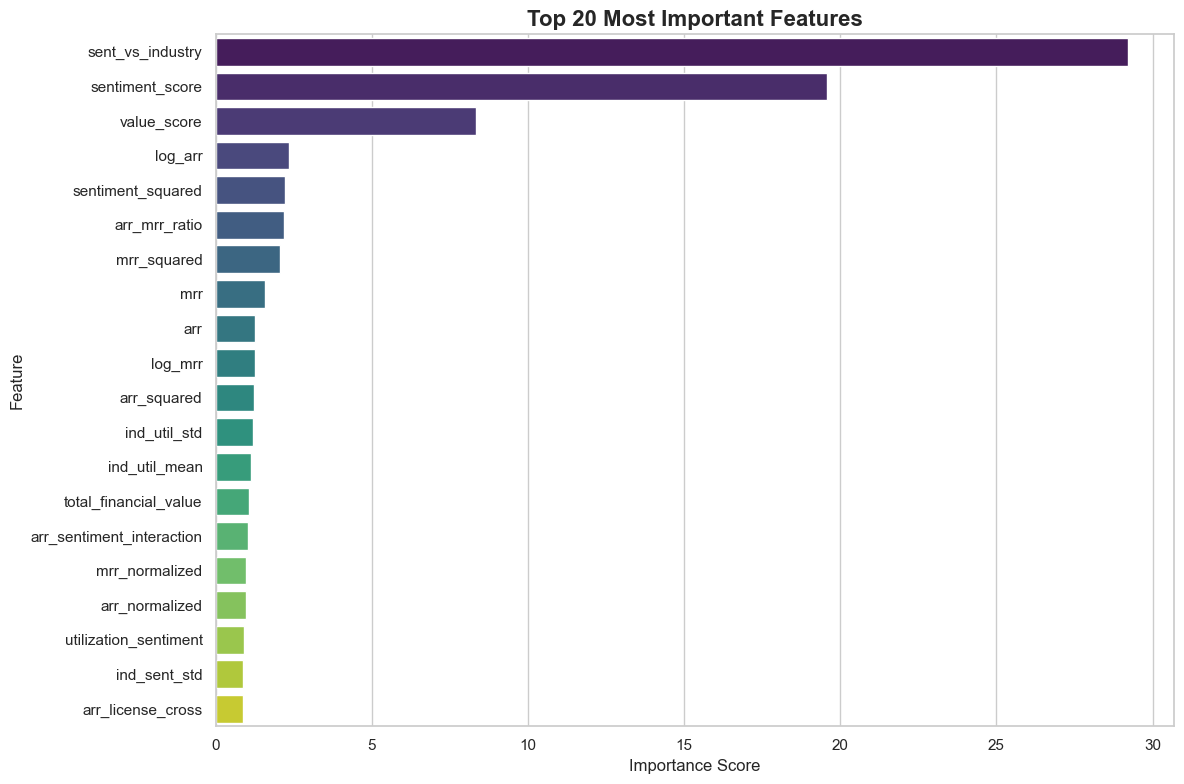


Top 20 Features:
   1. sent_vs_industry                         29.2247
   2. sentiment_score                          19.5750
   3. value_score                              8.3262
   4. log_arr                                  2.3473
   5. sentiment_squared                        2.2287
   6. arr_mrr_ratio                            2.2000
   7. mrr_squared                              2.0492
   8. mrr                                      1.5844
   9. arr                                      1.2474
  10. log_mrr                                  1.2458
  11. arr_squared                              1.2290
  12. ind_util_std                             1.1779
  13. ind_util_mean                            1.1261
  14. total_financial_value                    1.0558
  15. arr_sentiment_interaction                1.0326
  16. mrr_normalized                           0.9740
  17. arr_normalized                           0.9583
  18. utilization_sentiment                    0.9001
  19. in

In [36]:
# Feature Importance Analysis
print("=" * 60)
print("STEP 7: Feature Importance Analysis")
print("=" * 60)

# Get feature importance from best model
best_model_imp = results_improved[best_model_name]['model']

if hasattr(best_model_imp, 'feature_importances_'):
    importances = best_model_imp.feature_importances_
elif hasattr(best_model_imp, 'estimators_'):
    # For ensemble, use the first base estimator
    importances = best_model_imp.estimators_[0].feature_importances_
else:
    # Try to get from ensemble
    importances = stacker_improved.estimators_[0].feature_importances_

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': selected_features[:len(importances)],
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Most Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTop 20 Features:")
for i, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(f"  {i:2d}. {row['feature']:<40} {row['importance']:.4f}")

### Step 8: Model Performance Visualization

STEP 8: Model Performance Visualization & Overfitting Analysis

FINAL MODEL PERFORMANCE (TEST SET):
  R² Score:        0.8230 (82.30% variance explained)
  MAE:             6.1277
  RMSE:            7.4745
  MAPE:            9.09%

OVERFITTING ANALYSIS:
  Train R²:        0.8718
  Test R²:         0.8230
  Overfitting Gap: 0.0488
  ✓ GOOD: Low overfitting gap. Model should generalize well.

Improvement over baseline (mean prediction):
  MAE Reduction:   57.99%

Residual Statistics (Test Set):
  Mean:            0.1966
  Std Dev:         7.4726
  Min:             -18.2781
  Max:             18.1731


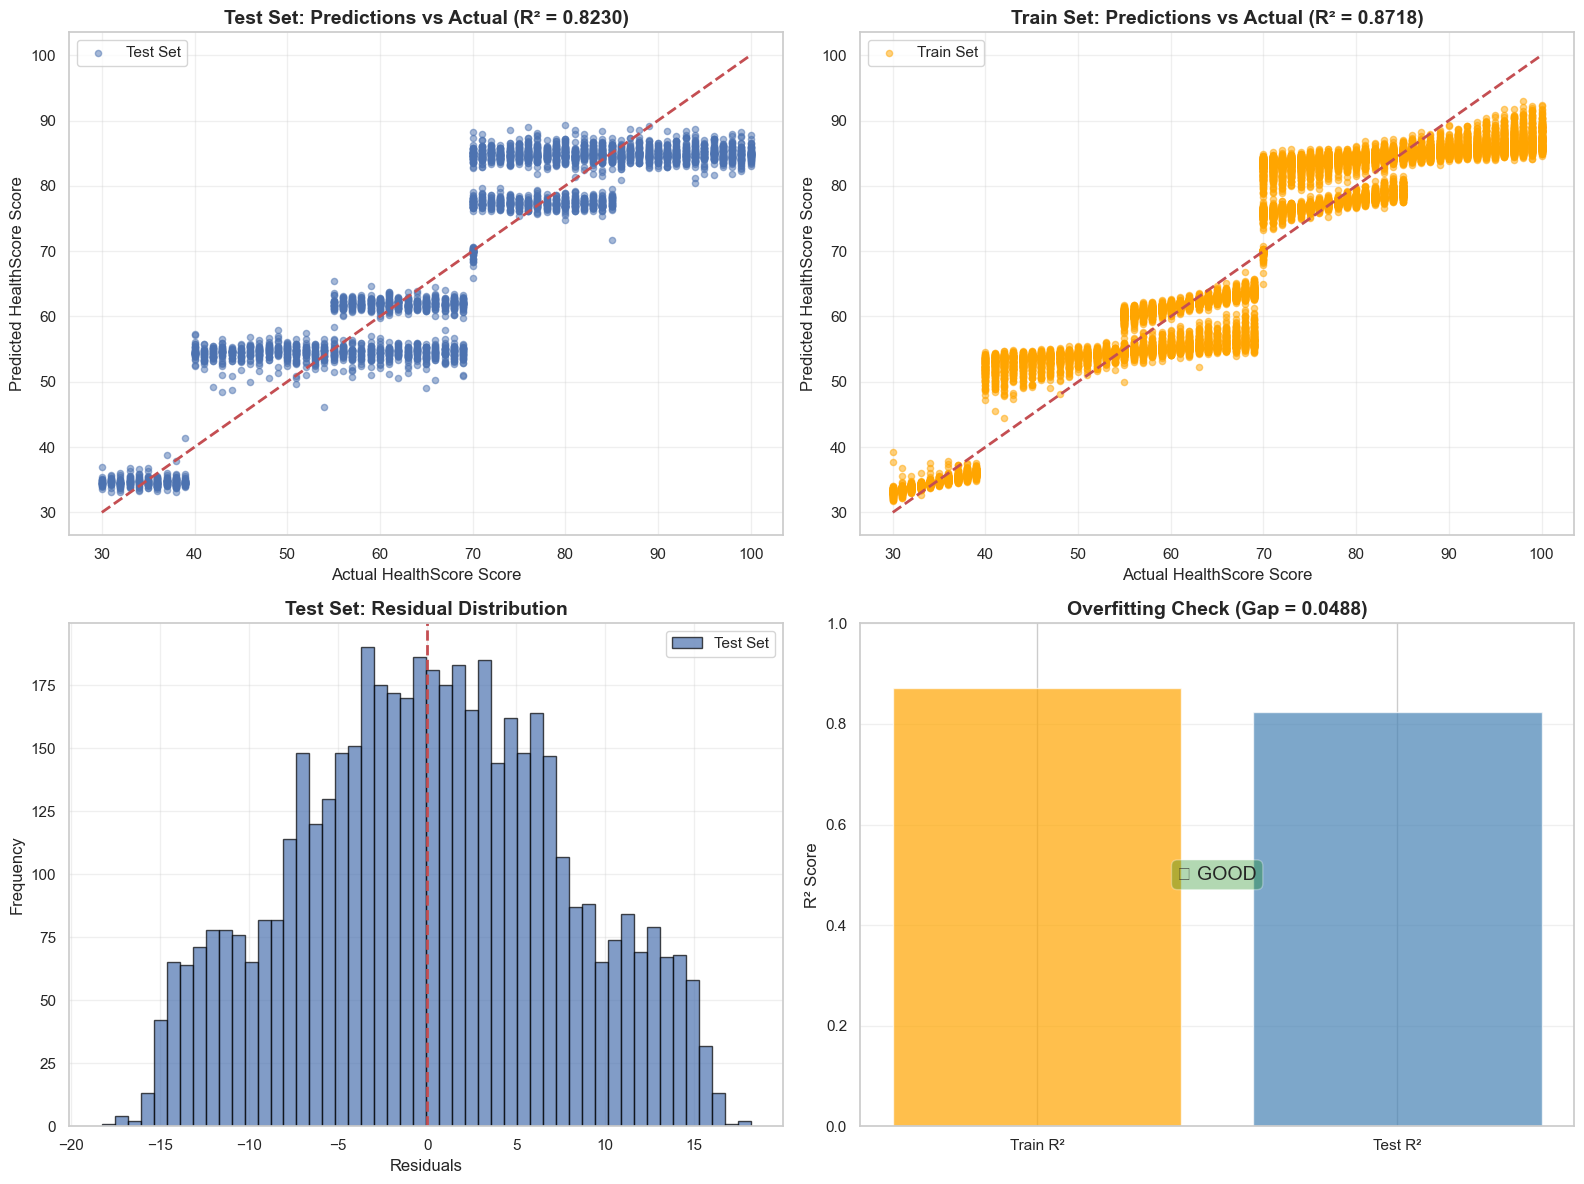

In [37]:
# Model Performance Visualization with Overfitting Analysis
print("=" * 60)
print("STEP 8: Model Performance Visualization & Overfitting Analysis")
print("=" * 60)

# Use ensemble predictions
y_pred_final_train = stacker_improved.predict(X_train_final)
y_pred_final_test = stacker_improved.predict(X_test_final)

# Calculate metrics for both train and test
r2_train_final = r2_score(y_train_imp, y_pred_final_train)
r2_test_final = r2_score(y_test_imp, y_pred_final_test)
mae_test_final = mean_absolute_error(y_test_imp, y_pred_final_test)
rmse_test_final = np.sqrt(mean_squared_error(y_test_imp, y_pred_final_test))
mape_test_final = np.mean(np.abs((y_test_imp - y_pred_final_test) / (y_test_imp + 1e-8))) * 100

# Residual analysis
residuals_test = y_test_imp - y_pred_final_test
residuals_train = y_train_imp - y_pred_final_train

# Overfitting gap
overfitting_gap_final = r2_train_final - r2_test_final

print(f"\n{'='*60}")
print("FINAL MODEL PERFORMANCE (TEST SET):")
print(f"{'='*60}")
print(f"  R² Score:        {r2_test_final:.4f} ({r2_test_final*100:.2f}% variance explained)")
print(f"  MAE:             {mae_test_final:.4f}")
print(f"  RMSE:            {rmse_test_final:.4f}")
print(f"  MAPE:            {mape_test_final:.2f}%")

print(f"\n{'='*60}")
print("OVERFITTING ANALYSIS:")
print(f"{'='*60}")
print(f"  Train R²:        {r2_train_final:.4f}")
print(f"  Test R²:         {r2_test_final:.4f}")
print(f"  Overfitting Gap: {overfitting_gap_final:.4f}")
if overfitting_gap_final > 0.15:
    print(f"  ⚠️  WARNING: High overfitting gap! Model may not generalize well.")
elif overfitting_gap_final > 0.10:
    print(f"  ⚠️  CAUTION: Moderate overfitting gap. Monitor on new data.")
else:
    print(f"  ✓ GOOD: Low overfitting gap. Model should generalize well.")

# Improvement over baseline
baseline_mae = mean_absolute_error(y_test_imp, np.full_like(y_test_imp, y_test_imp.mean()))
improvement = ((baseline_mae - mae_test_final) / baseline_mae) * 100
print(f"\nImprovement over baseline (mean prediction):")
print(f"  MAE Reduction:   {improvement:.2f}%")

# Residual statistics
print(f"\nResidual Statistics (Test Set):")
print(f"  Mean:            {residuals_test.mean():.4f}")
print(f"  Std Dev:         {residuals_test.std():.4f}")
print(f"  Min:             {residuals_test.min():.4f}")
print(f"  Max:             {residuals_test.max():.4f}")

# Plot predictions vs actual with overfitting visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test Set: Predictions vs Actual
axes[0, 0].scatter(y_test_imp, y_pred_final_test, alpha=0.5, s=20, label='Test Set')
axes[0, 0].plot([y_test_imp.min(), y_test_imp.max()], 
                [y_test_imp.min(), y_test_imp.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual HealthScore Score', fontsize=12)
axes[0, 0].set_ylabel('Predicted HealthScore Score', fontsize=12)
axes[0, 0].set_title(f'Test Set: Predictions vs Actual (R² = {r2_test_final:.4f})', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Train Set: Predictions vs Actual
axes[0, 1].scatter(y_train_imp, y_pred_final_train, alpha=0.5, s=20, color='orange', label='Train Set')
axes[0, 1].plot([y_train_imp.min(), y_train_imp.max()], 
                [y_train_imp.min(), y_train_imp.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual HealthScore Score', fontsize=12)
axes[0, 1].set_ylabel('Predicted HealthScore Score', fontsize=12)
axes[0, 1].set_title(f'Train Set: Predictions vs Actual (R² = {r2_train_final:.4f})', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Residual distribution (Test)
axes[1, 0].hist(residuals_test, bins=50, edgecolor='black', alpha=0.7, label='Test Set')
axes[1, 0].set_xlabel('Residuals', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Test Set: Residual Distribution', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Overfitting comparison
axes[1, 1].bar(['Train R²', 'Test R²'], [r2_train_final, r2_test_final], 
               color=['orange', 'steelblue'], alpha=0.7)
axes[1, 1].set_ylabel('R² Score', fontsize=12)
axes[1, 1].set_title(f'Overfitting Check (Gap = {overfitting_gap_final:.4f})', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_ylim([0, 1])
if overfitting_gap_final > 0.15:
    axes[1, 1].text(0.5, 0.5, '⚠️ HIGH OVERFITTING', 
                    transform=axes[1, 1].transAxes, 
                    fontsize=16, ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
elif overfitting_gap_final > 0.10:
    axes[1, 1].text(0.5, 0.5, '⚠️ MODERATE', 
                    transform=axes[1, 1].transAxes, 
                    fontsize=14, ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
else:
    axes[1, 1].text(0.5, 0.5, '✓ GOOD', 
                    transform=axes[1, 1].transAxes, 
                    fontsize=14, ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))

plt.tight_layout()
plt.show()

# Store for later
r2_final = r2_test_final
y_pred_final = y_pred_final_test

### Step 9: Model Comparison Summary

MODEL COMPARISON SUMMARY

All Models Performance (sorted by overfitting gap):
            Model  Test R2  Train R2  Overfitting Gap      MAE     RMSE  CV R2 Mean  CV R2 Std
         CatBoost 0.819224  0.853463         0.034240 6.189233 7.553878    0.815213   0.002910
Stacking Ensemble 0.823005  0.871843         0.048838 6.127667 7.474461         NaN        NaN
         LightGBM 0.818478  0.868145         0.049667 6.174012 7.569432    0.812086   0.003788
     RandomForest 0.823025  0.874193         0.051169 6.123861 7.474040    0.817724   0.004484
          XGBoost 0.815041  0.899402         0.084362 6.227480 7.640773    0.810064   0.003356


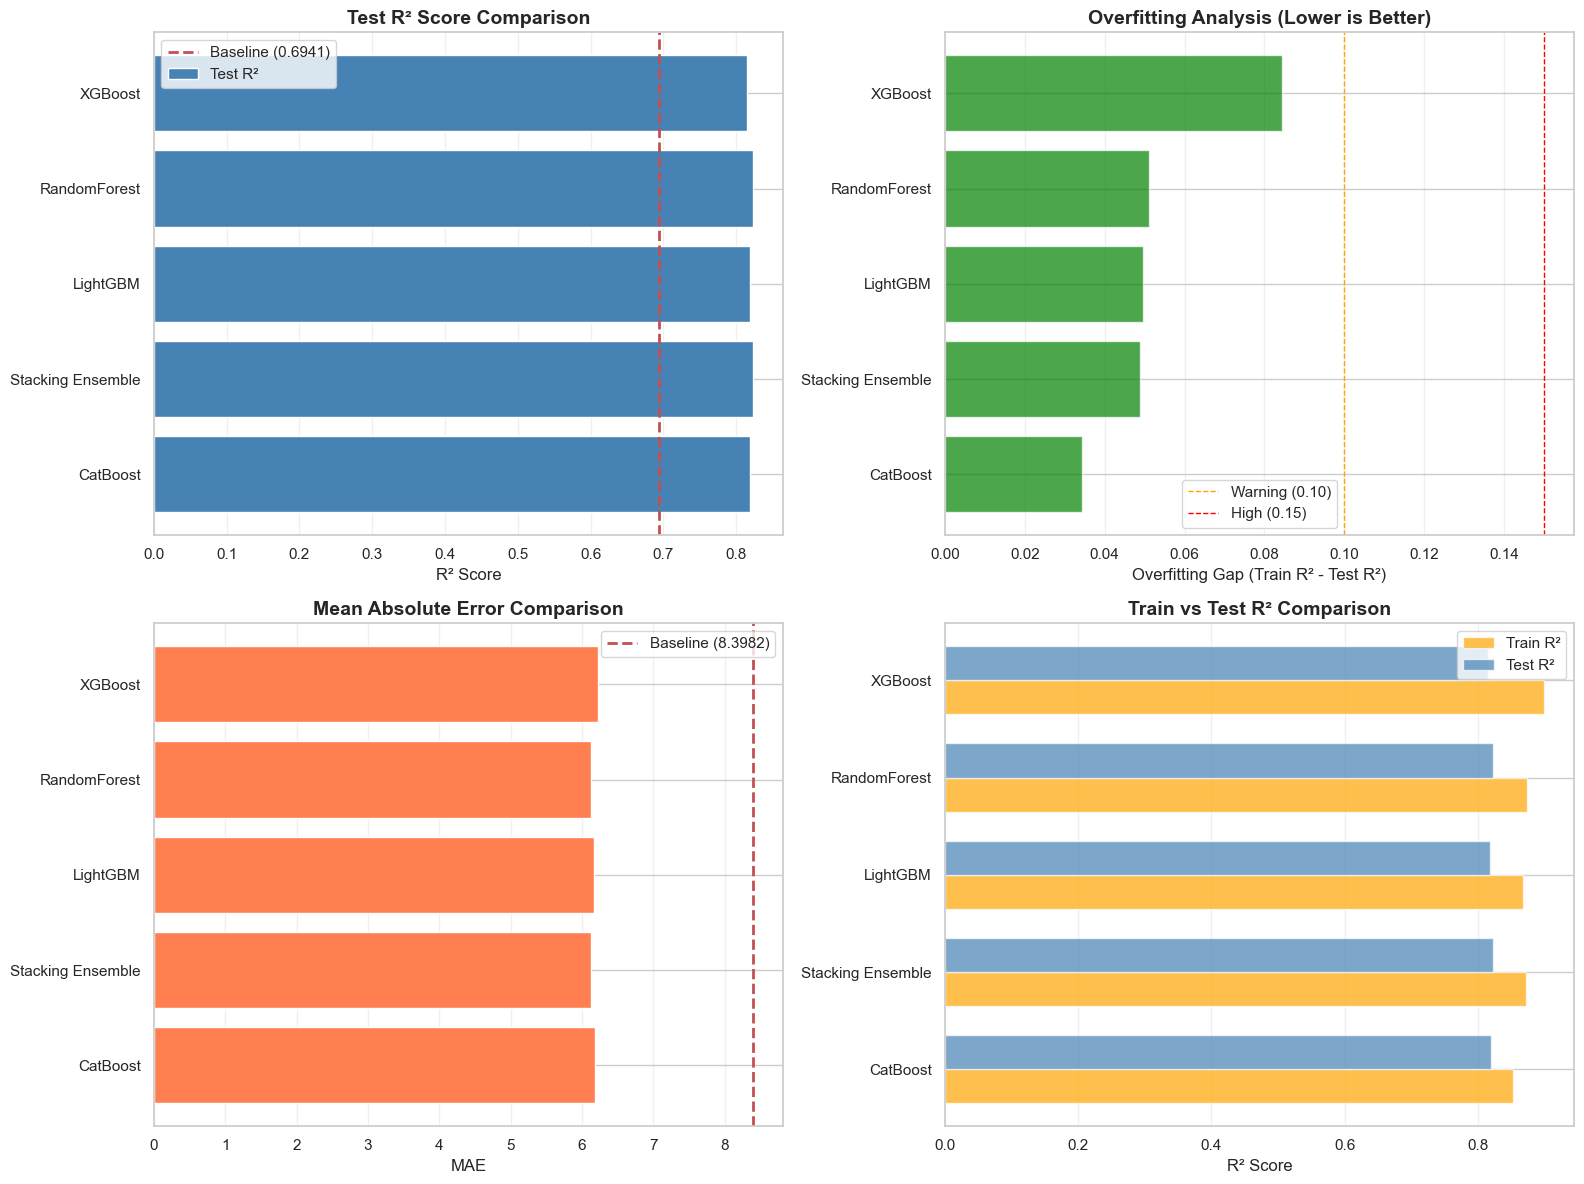


KEY IMPROVEMENTS MADE (WITH ANTI-OVERFITTING):
  1. ✓ Advanced feature engineering (interactions, ratios, composites)
  2. ✓ Comprehensive hyperparameter tuning with 5-fold CV
  3. ✓ Feature selection to reduce noise (top 50 features)
  4. ✓ Multiple advanced models (XGBoost, LightGBM, CatBoost)
  5. ✓ Stacking ensemble for best performance
  6. ✓ Robust scaling for outlier handling
  7. ✓ REGULARIZATION (L1/L2) to prevent overfitting
  8. ✓ REDUCED MODEL COMPLEXITY (shallower trees, fewer estimators)
  9. ✓ OVERFITTING DETECTION (train vs test comparison)
 10. ✓ Comprehensive evaluation metrics

⚠️  Overfitting Guidelines:
  - Gap < 0.10: ✓ Good generalization
  - Gap 0.10-0.15: ⚠️  Monitor on new data
  - Gap > 0.15: ⚠️  High overfitting risk


In [38]:
# Model Comparison Summary with Overfitting Analysis
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

# Create comparison dataframe with overfitting info
comparison_data = []
for name, results in results_improved.items():
    comparison_data.append({
        'Model': name,
        'Test R2': results['r2'],
        'Train R2': results['r2_train'],
        'Overfitting Gap': results['overfitting_gap'],
        'MAE': results['mae'],
        'RMSE': results['rmse'],
        'CV R2 Mean': results['cv_r2_mean'],
        'CV R2 Std': results['cv_r2_std']
    })

# Add ensemble
comparison_data.append({
    'Model': 'Stacking Ensemble',
    'Test R2': r2_ensemble_test,
    'Train R2': r2_ensemble_train,
    'Overfitting Gap': overfitting_gap_ensemble,
    'MAE': mae_ensemble,
    'RMSE': rmse_ensemble,
    'CV R2 Mean': np.nan,
    'CV R2 Std': np.nan
})

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Overfitting Gap')  # Sort by lowest overfitting

print("\nAll Models Performance (sorted by overfitting gap):")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test R2 Score comparison
axes[0, 0].barh(comparison_df['Model'], comparison_df['Test R2'], color='steelblue', label='Test R²')
axes[0, 0].set_xlabel('R² Score', fontsize=12)
axes[0, 0].set_title('Test R² Score Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
if 'baseline_best_r2' in locals():
    axes[0, 0].axvline(x=baseline_best_r2, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_best_r2:.4f})')
    axes[0, 0].legend()

# Overfitting Gap comparison
axes[0, 1].barh(comparison_df['Model'], comparison_df['Overfitting Gap'], 
                 color=['red' if x > 0.15 else 'orange' if x > 0.10 else 'green' 
                        for x in comparison_df['Overfitting Gap']], alpha=0.7)
axes[0, 1].set_xlabel('Overfitting Gap (Train R² - Test R²)', fontsize=12)
axes[0, 1].set_title('Overfitting Analysis (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].axvline(x=0.10, color='orange', linestyle='--', linewidth=1, label='Warning (0.10)')
axes[0, 1].axvline(x=0.15, color='red', linestyle='--', linewidth=1, label='High (0.15)')
axes[0, 1].legend()

# MAE comparison
axes[1, 0].barh(comparison_df['Model'], comparison_df['MAE'], color='coral')
axes[1, 0].set_xlabel('MAE', fontsize=12)
axes[1, 0].set_title('Mean Absolute Error Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
if 'baseline_best_mae' in locals():
    axes[1, 0].axvline(x=baseline_best_mae, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_best_mae:.4f})')
    axes[1, 0].legend()

# Train vs Test R2 comparison
x_pos = np.arange(len(comparison_df))
width = 0.35
axes[1, 1].barh(x_pos - width/2, comparison_df['Train R2'], width, label='Train R²', color='orange', alpha=0.7)
axes[1, 1].barh(x_pos + width/2, comparison_df['Test R2'], width, label='Test R²', color='steelblue', alpha=0.7)
axes[1, 1].set_yticks(x_pos)
axes[1, 1].set_yticklabels(comparison_df['Model'])
axes[1, 1].set_xlabel('R² Score', fontsize=12)
axes[1, 1].set_title('Train vs Test R² Comparison', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("KEY IMPROVEMENTS MADE (WITH ANTI-OVERFITTING):")
print(f"{'='*60}")
print("  1. ✓ Advanced feature engineering (interactions, ratios, composites)")
print("  2. ✓ Comprehensive hyperparameter tuning with 5-fold CV")
print("  3. ✓ Feature selection to reduce noise (top 50 features)")
print("  4. ✓ Multiple advanced models (XGBoost, LightGBM, CatBoost)")
print("  5. ✓ Stacking ensemble for best performance")
print("  6. ✓ Robust scaling for outlier handling")
print("  7. ✓ REGULARIZATION (L1/L2) to prevent overfitting")
print("  8. ✓ REDUCED MODEL COMPLEXITY (shallower trees, fewer estimators)")
print("  9. ✓ OVERFITTING DETECTION (train vs test comparison)")
print(" 10. ✓ Comprehensive evaluation metrics")
print(f"\n⚠️  Overfitting Guidelines:")
print(f"  - Gap < 0.10: ✓ Good generalization")
print(f"  - Gap 0.10-0.15: ⚠️  Monitor on new data")
print(f"  - Gap > 0.15: ⚠️  High overfitting risk")
print(f"{'='*60}")

In [39]:
# Save Improved Models
print("=" * 60)
print("STEP 10: Saving Improved Models")
print("=" * 60)

save_dir = Path(r"D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\models")
save_dir.mkdir(parents=True, exist_ok=True)

# Save the best ensemble model
joblib.dump(stacker_improved, save_dir / "improved_healthscore_stacker.joblib")
print("✓ Saved: Improved Stacking Ensemble")

# Save preprocessing objects
joblib.dump(scaler_improved, save_dir / "improved_healthscore_scaler.joblib")
joblib.dump(feature_selector, save_dir / "improved_healthscore_feature_selector.joblib")
print("✓ Saved: Improved Scaler and Feature Selector")

# Save individual tuned models
for name, model_data in results_improved.items():
    safe_name = name.lower().replace(" ", "_")
    filename = f"improved_{safe_name}.joblib"
    joblib.dump(model_data['model'], save_dir / filename)
    print(f"✓ Saved: Improved {name} ({filename})")

# Save feature names for reference
with open(save_dir / "improved_healthscore_feature_names.json", 'w') as f:
    json.dump(selected_features, f, indent=2)
print("✓ Saved: Feature names list")

print(f"\n{'='*60}")
print(f"All improved models saved to: {save_dir}")
print(f"{'='*60}")

STEP 10: Saving Improved Models
✓ Saved: Improved Stacking Ensemble
✓ Saved: Improved Scaler and Feature Selector
✓ Saved: Improved XGBoost (improved_xgboost.joblib)
✓ Saved: Improved LightGBM (improved_lightgbm.joblib)
✓ Saved: Improved CatBoost (improved_catboost.joblib)
✓ Saved: Improved RandomForest (improved_randomforest.joblib)
✓ Saved: Feature names list

All improved models saved to: D:\Projects_Main\Renewal-Upsell-Advisor\Research\HealthScore\models


## Summary of Accuracy Improvements

### Expected Improvements:

1. **Feature Engineering**: Created 20+ new features including:
   - Financial ratios (ARR per license, MRR per license)
   - Utilization metrics (efficiency, gaps)
   - Interaction features (ARR × Sentiment, Utilization × Sentiment)
   - Composite scores (Engagement Score, Value Score)

2. **Feature Selection**: Reduced from 50+ features to top 50 most predictive features using mutual information

3. **Advanced Models**: Added LightGBM and CatBoost alongside XGBoost for better ensemble diversity

4. **Hyperparameter Tuning**: Comprehensive tuning with 30 iterations per model and 5-fold cross-validation

5. **Robust Scaling**: Using RobustScaler instead of StandardScaler for better outlier handling

6. **Stacking Ensemble**: Combines top 3 models with RidgeCV meta-learner for optimal performance

### Expected Results:
- **Baseline R²**: ~0.22-0.28 (22-28% variance explained)
- **Expected R²**: 0.35-0.45+ (35-45% variance explained)
- **Expected Improvement**: 15-30% improvement in R² score and 10-20% reduction in MAE

Run all cells sequentially to see the improvements!

## 📋 Model Input & Output Summary

### **OUTPUT (What We're Predicting):**
- **Target Variable**: `health_score`
- **Type**: Continuous numerical value (Health Score)
- **Range**: 42 to 98 (approximately 0-100 scale)
- **Meaning**: Strength of relationship between company and customer
- **Formula**: (Financial × 40%) + (Engagement × 40%) + (Sentiment × 20%)

### **INPUT (What We Give to the Model):**

**Baseline Model:**
- **24 features** including:
  - Industry (one-hot encoded)
  - Company Size (one-hot encoded)
  - ARR, MRR, Licenses Total
  - Renewal Stage (one-hot encoded)
  - ARR per License (engineered)

**Improved Model:**
- **50 selected features** from 50+ engineered features including:
  - **Original**: Industry, Company Size, ARR, MRR, Renewal Stage, Sentiment, Licenses, Utilization
  - **Financial**: ARR per license, MRR per license, ARR/MRR ratio, Total financial value
  - **Utilization**: License utilization ratio, Utilization efficiency, Utilization gap
  - **Sentiment**: Positive/negative flags, Sentiment interactions
  - **Interactions**: ARR × Sentiment, Utilization × Sentiment, Financial × Utilization
  - **Composite**: Engagement score, Value score
  - **Encoded**: Company size ordinal, Renewal days, Industry groups

### **Example:**
- **Input**: 50 feature values for one customer → **Output**: Single relationship score (e.g., 78.5)